In [ ]:
# ==========================================
# SETUP & DATA LOADING
# ==========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# ================== CONFIGURATION ==================
# UPDATE THIS PATH to matches your specific Google Drive location
DATA_PATH     = "/content/drive/My Drive/DeepLearning_Project/pems03_h.csv"
DATA_DIR      = "/content/pems03_processed"  # Local temp storage
TIMESTAMP_COL = "date"
LOOKBACK      = 12    # 12 hours context
VAL_FRAC      = 0.1
TEST_FRAC     = 0.1

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

# 2. Load Data
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found at {DATA_PATH}. Check Drive path.")

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Convert timestamp
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
df = df.sort_values(TIMESTAMP_COL)
print(f"Data Loaded. Shape: {df.shape}")

# 3. Preprocessing
# Drop non-numeric columns
data_numeric = df.drop(columns=[TIMESTAMP_COL])
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_numeric)

# Save scaler for inverse transform later
joblib.dump(scaler, os.path.join(DATA_DIR, "scaler.pkl"))

# Create Sequences (Windowing)
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

# Split Data
n = len(scaled_data)
n_val = int(n * VAL_FRAC)
n_test = int(n * TEST_FRAC)
n_train = n - n_val - n_test

train_data = scaled_data[:n_train]
val_data   = scaled_data[n_train : n_train+n_val]
test_data  = scaled_data[n_train+n_val:]

X_train, y_train = create_sequences(train_data, LOOKBACK)
X_val, y_val     = create_sequences(val_data, LOOKBACK)
X_test, y_test   = create_sequences(test_data, LOOKBACK)

print(f"Train Shape: {X_train.shape}")
print(f"Val Shape:   {X_val.shape}")
print(f"Test Shape:  {X_test.shape}")

Mounted at /content/drive
Loading dataset from: /content/drive/My Drive/DeepLearning_Project/pems03_h.csv
Data Loaded. Shape: (191136, 152)
Train Shape: (152898, 12, 151)
Val Shape:   (19101, 12, 151)
Test Shape:  (19101, 12, 151)


In [ ]:
# ==========================================
# MODEL ARCHITECTURES
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, Flatten, TimeDistributed, Reshape
from tensorflow.keras.optimizers import Adam

# --- 1. Stacked LSTM (Deep) ---
def build_lstm_model(input_shape):
    """
    Stacked LSTM: 128 units -> 64 units
    Matches research paper complexity.
    """
    model = Sequential([
        # Layer 1: High capacity, return_sequences=True to feed next LSTM
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        # Layer 2: Refinement
        LSTM(64, return_sequences=False),
        Dropout(0.2),

        # Output
        Dense(input_shape[1])
    ], name="Stacked_LSTM")

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# --- 2. Stacked GRU (Deep) ---
def build_gru_model(input_shape):
    """
    Stacked GRU: 128 units -> 64 units
    """
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(input_shape[1])
    ], name="Stacked_GRU")

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# --- 3. Optimized CNN-LSTM (Hybrid) ---
def build_cnn_lstm_model(input_shape):
    """
    Optimized Spatio-Temporal Model.
    Uses TimeDistributed CNN to process each time step independently.
    """
    model = Sequential([
        # Reshape to (Time, 1, Features) for 1D Convolution on features
        Reshape((input_shape[0], input_shape[1], 1), input_shape=input_shape),

        # CNN Feature Extractor (Applied to each time step)
        TimeDistributed(Conv1D(filters=64, kernel_size=1, activation='relu')),
        TimeDistributed(Flatten()),
        Dropout(0.1),

        # LSTM Temporal Processor
        LSTM(64, return_sequences=False),
        Dropout(0.1),

        Dense(input_shape[1])
    ], name="Optimized_CNN_LSTM")

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

print("All Models Defined (Stacked LSTM/GRU + Optimized CNN-LSTM)")


All Models Defined (Stacked LSTM/GRU + Optimized CNN-LSTM)


In [ ]:
# --- Print Summaries for Verification ---
dummy_input_shape = (12, 151) # 12 steps lookback, 151 features (sensors)

print("\n--- LSTM Summary ---")
temp_lstm = build_lstm_model(dummy_input_shape)
temp_lstm.summary()

print("\n--- GRU Summary ---")
temp_gru = build_gru_model(dummy_input_shape)
temp_gru.summary()

print("\n--- CNN-LSTM Summary ---")
temp_cnn = build_cnn_lstm_model(dummy_input_shape)
temp_cnn.summary()



--- LSTM Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │       143,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 151)            │         9,815 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,583 (791.34 KB)

...

Model: "Optimized_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 12, 151, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 12, 151, 64)    │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 12, 9664)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 9664)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │     2,490,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 151)            │         9,815 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,500,567 (9.54 MB)

 Trainable params: 2,500,567 (9.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# TRAINING LOOP
# ==========================================
import time
from tensorflow.keras.callbacks import EarlyStopping

# Settings
EPOCHS = 15
BATCH_SIZE = 64

model_results = {}
model_histories = {}
predictions = {}

# Define models to train
models_to_train = [
    ("LSTM", build_lstm_model),
    ("GRU", build_gru_model),
    ("CNN-LSTM", build_cnn_lstm_model)
]

input_shape = (X_train.shape[1], X_train.shape[2])

for name, builder in models_to_train:
    print(f"\n{'='*40}")
    print(f"TRAINING MODEL: {name}")
    print(f"{'='*40}")

    model = builder(input_shape)

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=1
    )
    duration = time.time() - start

    # Store History & Time
    model_histories[name] = history
    model_results[name] = {'Time': duration}

    # Store Predictions (Inverse Transform for Real Values)
    print(f"Generating predictions for {name}...")
    pred_scaled = model.predict(X_test)
    predictions[name] = scaler.inverse_transform(pred_scaled)

    print(f"{name} Finished. Time: {duration:.2f}s")

print("\nAll Models Trained Successfully!")


TRAINING MODEL: LSTM
Epoch 1/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0125 - mae: 0.0726 - val_loss: 0.0065 - val_mae: 0.0522
Epoch 2/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0046 - mae: 0.0460 - val_loss: 0.0058 - val_mae: 0.0499
Epoch 3/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0042 - mae: 0.0448 - val_loss: 0.0056 - val_mae: 0.0480
Epoch 4/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0041 - mae: 0.0442 - val_loss: 0.0055 - val_mae: 0.0471
Epoch 5/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0040 - mae: 0.0438 - val_loss: 0.0053 - val_mae: 0.0467
Epoch 6/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0040 - mae: 0.0435 - val_loss: 0.0053 - val_mae: 0.0463
Epoch 7/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0039 - mae: 0.0432 - val_loss: 0.0051 - val_mae: 0.0451
Epoch 8/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0039 - mae: 0.0430 - val_loss: 0.0052 - val_mae: 0.0457
Epoch 9/15

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0126 - mae: 0.0733 - val_loss: 0.0060 - val_mae: 0.0503
Epoch 2/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0046 - mae: 0.0469 - val_loss: 0.0057 - val_mae: 0.0491
Epoch 3/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0043 - mae: 0.0456 - val_loss: 0.0053 - val_mae: 0.0476
Epoch 4/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0042 - mae: 0.0450 - val_loss: 0.0053 - val_mae: 0.0464
Epoch 5/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0041 - mae: 0.0446 - val_loss: 0.0051 - val_mae: 0.0466
Epoch 6/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0040 - mae: 0.0443 - val_loss: 0.0050 - val_mae: 0.0452
Epoch 7/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0040 - mae: 0.0440 - val_loss: 0.0050 - val_mae: 0.0457
Epoch 8/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0040 - mae: 0.0439 - val_loss: 0.0048 - val_mae: 0.0440
Epoch 9/15
2390/2390 ━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 51s 20ms/step - loss: 0.0097 - mae: 0.0636 - val_loss: 0.0051 - val_mae: 0.0462
Epoch 2/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 47s 19ms/step - loss: 0.0034 - mae: 0.0400 - val_loss: 0.0048 - val_mae: 0.0449
Epoch 3/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - loss: 0.0031 - mae: 0.0381 - val_loss: 0.0046 - val_mae: 0.0434
Epoch 4/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - loss: 0.0030 - mae: 0.0376 - val_loss: 0.0047 - val_mae: 0.0450
Epoch 5/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - loss: 0.0030 - mae: 0.0375 - val_loss: 0.0044 - val_mae: 0.0424
Epoch 6/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - loss: 0.0029 - mae: 0.0369 - val_loss: 0.0043 - val_mae: 0.0424
Epoch 7/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 47s 19ms/step - loss: 0.0029 - mae: 0.0368 - val_loss: 0.0042 - val_mae: 0.0413
Epoch 8/15
2390/2390 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - loss: 0.0028 - mae: 0.0366 - val_loss: 0.0043 - val_mae: 0.0425
Epoch 9/15
2390/2390 ━━━


=== FINAL COMPARATIVE RESULTS ===
      Model         MAE        RMSE  Training Time (s)
0      LSTM  255.143677  514.469525         269.321936
1       GRU  259.173888  500.637334         259.202231
2  CNN-LSTM  250.162377  493.467875         470.858845


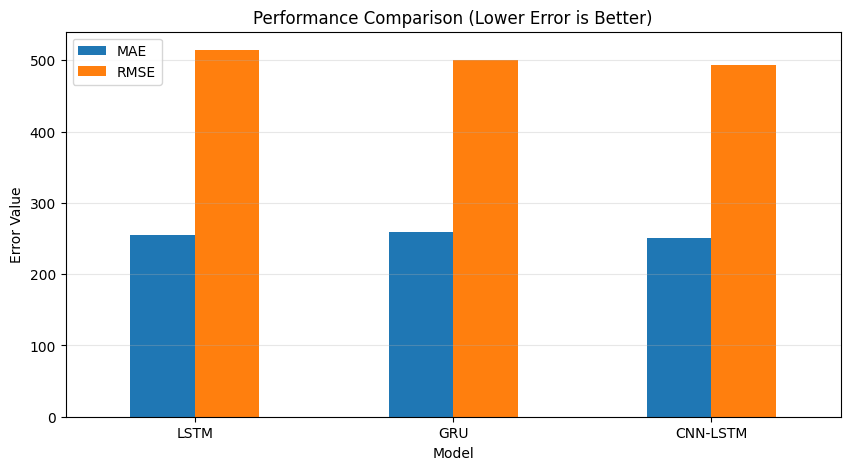

In [ ]:
# ==========================================
# FINAL METRICS & TABLE
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get Real Test Data (Inverse Transformed)
y_test_real = scaler.inverse_transform(y_test)

metrics_table = []

for name in model_results.keys():
    mse = mean_squared_error(y_test_real, predictions[name])
    mae = mean_absolute_error(y_test_real, predictions[name])
    rmse = np.sqrt(mse)

    metrics_table.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "Training Time (s)": model_results[name]['Time']
    })

metrics_df = pd.DataFrame(metrics_table)
print("\n=== FINAL COMPARATIVE RESULTS ===")
print(metrics_df)

# Bar Chart
metrics_df.plot(x="Model", y=["MAE", "RMSE"], kind="bar", figsize=(10, 5), rot=0)
plt.title("Performance Comparison (Lower Error is Better)")
plt.ylabel("Error Value")
plt.grid(axis='y', alpha=0.3)
plt.show()

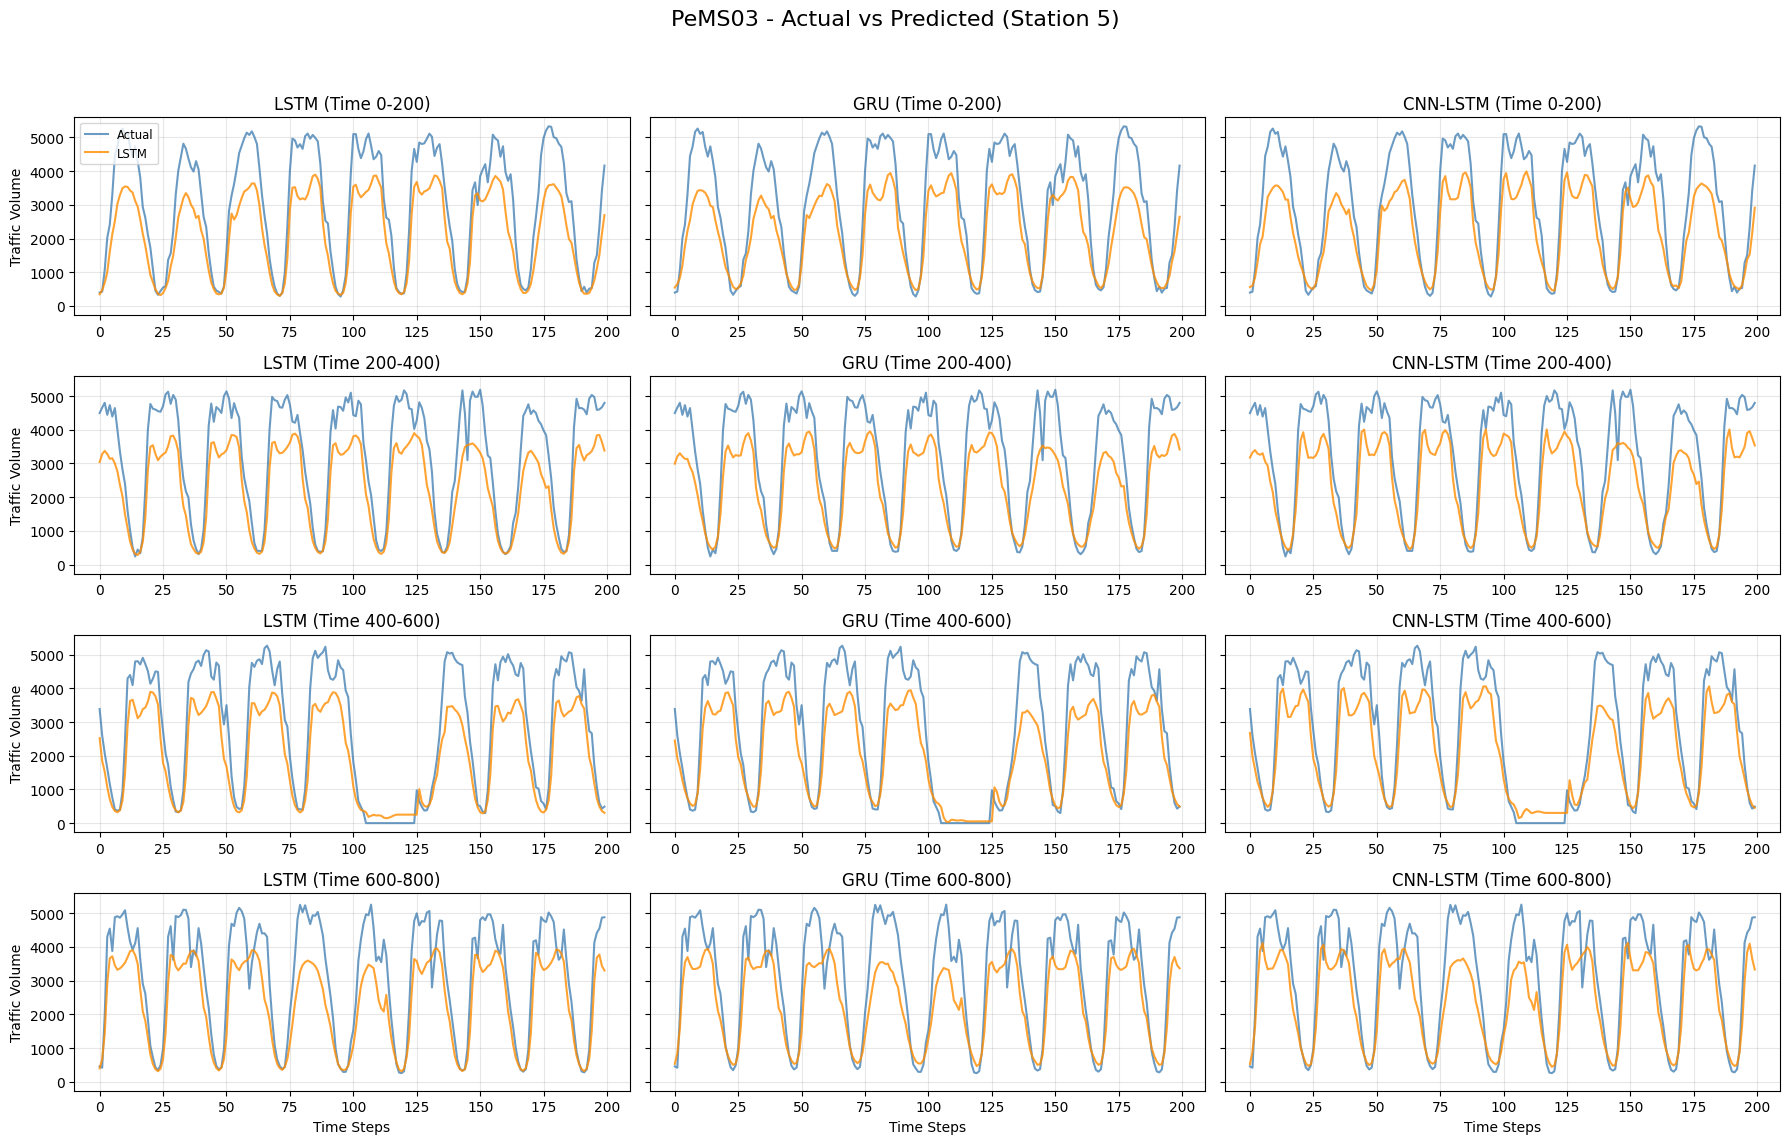

In [ ]:
# ==========================================
# DETAILED GRID VISUALIZATION
# ==========================================
# This recreates the 4-row specific time window plot
# Columns: LSTM | GRU | CNN-LSTM

windows = [
    (0, 200),
    (200, 400),
    (400, 600),
    (600, 800)
]
station_idx = 5  # Plotting the first station

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12), sharey=True)
fig.suptitle(f"PeMS03 - Actual vs Predicted (Station {station_idx})", fontsize=16)

models_ordered = ["LSTM", "GRU", "CNN-LSTM"]

for i, (start, end) in enumerate(windows):
    actual_segment = y_test_real[start:end, station_idx]

    for j, model_name in enumerate(models_ordered):
        ax = axes[i, j]
        pred_segment = predictions[model_name][start:end, station_idx]

        # Plot
        ax.plot(actual_segment, label="Actual", color='steelblue', linewidth=1.5, alpha=0.8)
        ax.plot(pred_segment, label=f"{model_name}", color='darkorange', linewidth=1.5, alpha=0.8)

        # Formatting
        ax.set_title(f"{model_name} (Time {start}-{end})")
        ax.grid(True, alpha=0.3)

        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize='small')
        if j == 0:
            ax.set_ylabel("Traffic Volume")
        if i == 3:
            ax.set_xlabel("Time Steps")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

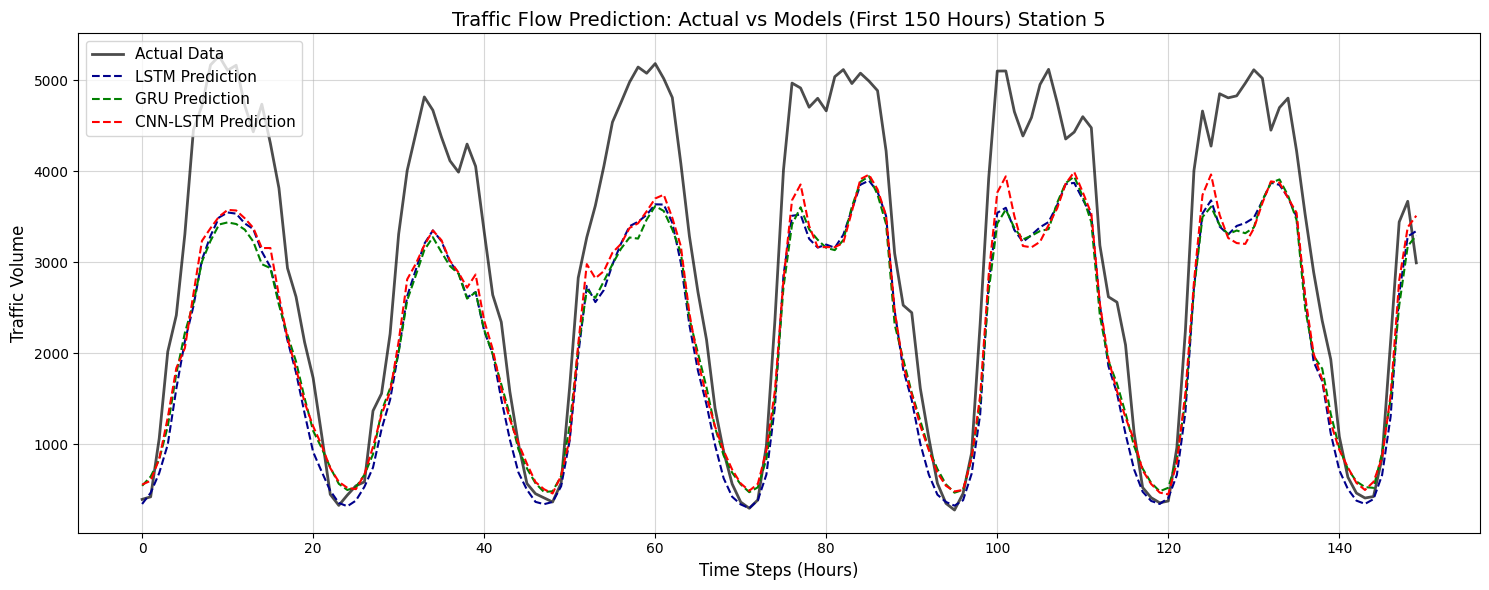

In [ ]:
# ==========================================
# ZOOMED OVERLAID COMPARISON (First 150 Hours)
# ==========================================
import matplotlib.pyplot as plt

# Settings
hours_to_plot = 150
station_idx = 5  # Plotting the first station (feature 0)

plt.figure(figsize=(15, 6))

# 1. Plot Actual Data (Black Solid Line)
# Note: Using inverse transformed data to show real traffic counts
plt.plot(y_test_real[:hours_to_plot, station_idx],
         label="Actual Data",
         color='black',
         linewidth=2,
         alpha=0.7)

# 2. Plot Model Predictions (Dashed Lines)
colors = {
    'LSTM': 'darkblue',
    'GRU': 'green',
    'CNN-LSTM': 'red'
}

# Loop through models and plot
for name in ["LSTM", "GRU", "CNN-LSTM"]:
    plt.plot(predictions[name][:hours_to_plot, station_idx],
             label=f"{name} Prediction",
             linestyle='--',
             linewidth=1.5,
             color=colors.get(name))

# 3. Formatting
plt.title(f"Traffic Flow Prediction: Actual vs Models (First {hours_to_plot} Hours) Station 5", fontsize=14)
plt.xlabel("Time Steps (Hours)", fontsize=12)
plt.ylabel("Traffic Volume", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.5)

# Show plot
plt.tight_layout()
plt.show()


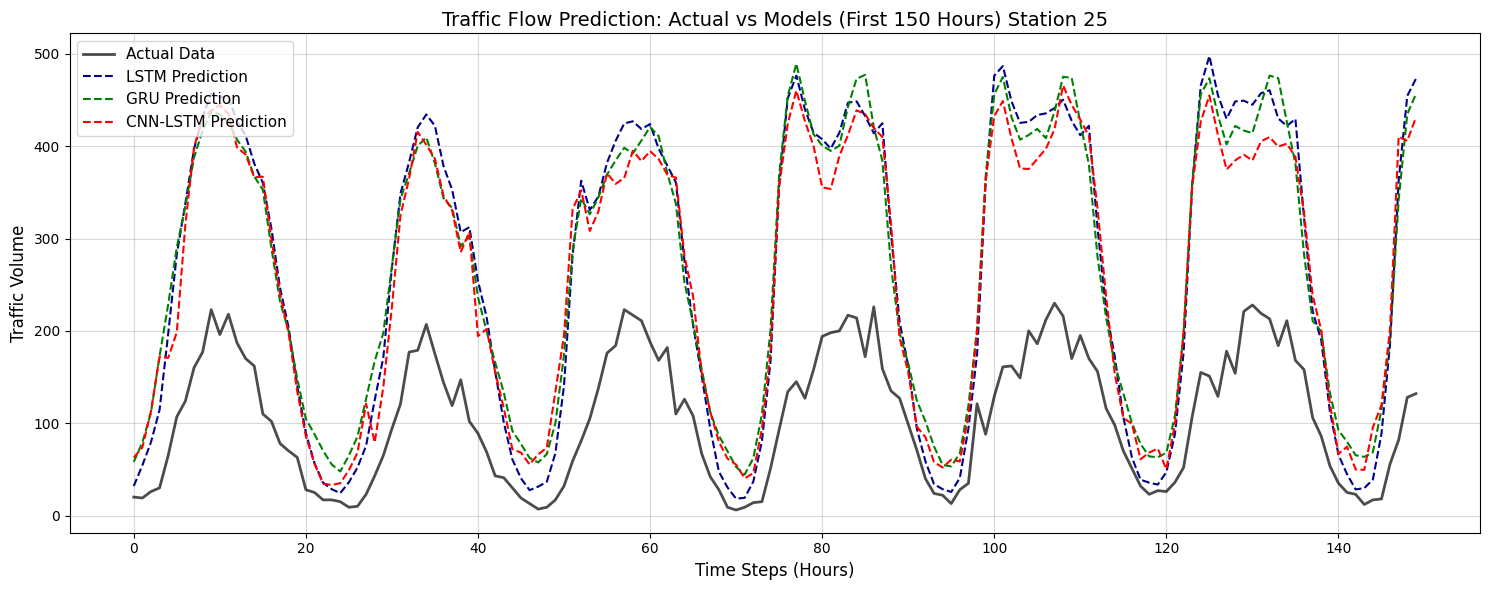

In [ ]:
# ==========================================
# ZOOMED OVERLAID COMPARISON (First 150 Hours)
# ==========================================
import matplotlib.pyplot as plt

# Settings
hours_to_plot = 150
station_idx = 25  # Plotting the first station (feature 0)

plt.figure(figsize=(15, 6))

# 1. Plot Actual Data (Black Solid Line)
# Note: Using inverse transformed data to show real traffic counts
plt.plot(y_test_real[:hours_to_plot, station_idx],
         label="Actual Data",
         color='black',
         linewidth=2,
         alpha=0.7)

# 2. Plot Model Predictions (Dashed Lines)
colors = {
    'LSTM': 'darkblue',
    'GRU': 'green',
    'CNN-LSTM': 'red'
}

# Loop through models and plot
for name in ["LSTM", "GRU", "CNN-LSTM"]:
    plt.plot(predictions[name][:hours_to_plot, station_idx],
             label=f"{name} Prediction",
             linestyle='--',
             linewidth=1.5,
             color=colors.get(name))

# 3. Formatting
plt.title(f"Traffic Flow Prediction: Actual vs Models (First {hours_to_plot} Hours) Station 25", fontsize=14)
plt.xlabel("Time Steps (Hours)", fontsize=12)
plt.ylabel("Traffic Volume", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.5)

# Show plot
plt.tight_layout()
plt.show()
